# Overview


# Definitions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

In [2]:
df = pd.read_csv("results/final_imagenet.csv", index_col=0)
df

,CPU TIME (ms),GPU TIME (ms),CPU MEMORY (MB),GPU MEMORY (MB),NCALLS,PEAK GPU MEMORY (MB),LENS,VISUALIZER,INPLACE,DEVICE
mt::initialization,0.116000,0.000000,0.000000,0.000000,1.0,4963.716309,baseline,NaN,True,cuda
mt::matplotlib_visualization,0.096570,0.000000,0.000000,0.000000,1.0,4963.716309,baseline,NaN,True,cuda
mt::training::backward_pass,15885.766196,0.097088,-0.004578,-87357.367676,25.0,4963.716309,baseline,NaN,True,cuda
mt::training::forward_pass,8671.740692,16050.522107,0.004578,95708.577148,25.0,4963.716309,baseline,NaN,True,cuda
mt::training::loss_computation,81.916860,29.422012,0.000000,3.064453,25.0,4963.716309,baseline,NaN,True,cuda
...,...,...,...,...,...,...,...,...,...,...
mt::training::backward_pass,17241.854047,0.103608,-0.004578,-87181.023926,25.0,7478.233887,ParameterNorm,tensorboard,False,cuda
mt::training::forward_pass,8403.049434,16777.345615,0.004578,95630.295898,25.0,7478.233887,ParameterNorm,tensorboard,False,cuda
mt::training::loss_computation,29.244469,2.633988,0.000000,3.064453,25.0,7478.233887,ParameterNorm,tensorboard,False,cuda
mt::training::optimizer_steps,731.800943,648.412166,0.000580,660.927734,25.0,7478.233887,ParameterNorm,tensorboard,False,cuda


In [3]:
def display_benchmark(df, training_part, metric, *, inplace, ax, step=0.25):
    df_ = df.loc[training_part, [metric, 'LENS', 'VISUALIZER', 'INPLACE', 'NCALLS']]
    baseline_val = df_[df_['LENS'] == 'baseline'][metric].iloc[0] / df_[df_['LENS'] == 'baseline']['NCALLS'].iloc[0]
    df_ = df_[(df_['INPLACE'] == inplace) & (df_['LENS'] != 'baseline')]

    df_[metric] /= df_['NCALLS']
    
    ax.set_title(f"{metric} / {training_part}")
    
    ax.axhline(baseline_val, c='red', label='baseline')
    sns.barplot(
        df_, x='LENS', y=metric, hue='VISUALIZER',
        ax=ax, zorder=0, legend='brief'
    )
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15
    )
    N = round((df_[metric].max() - baseline_val) / (step * baseline_val + 1e-9)) + 1
    if N < 15:
     
        rel_yticks = [baseline_val, baseline_val * 1.1] + [baseline_val * (1 + step * k) for k in range(1, N)]
        rel_yticklabels =["+0%", "+10%"] + [f"+{step * 100 * k}%" for k in range(1, N)]
        ax_min, ax_max = ax.get_ylim()[0], max(rel_yticks)
        axr = ax.twinx()
        if not np.isclose(ax_min, ax_max):
            axr.set_ylim(ax_min, ax_max)
            ax.set_ylim(ax_min, ax_max)
        axr.set_yticks(rel_yticks, rel_yticklabels)

        axr.grid(zorder=3)
    ax.legend()
    ax.set_xlabel("Lens")

## Initalization, Training and Visualisation Benchmarks

In [4]:
metrics = ['CPU TIME (ms)', 'GPU TIME (ms)', 'CPU MEMORY (MB)', 'GPU MEMORY (MB)', 'PEAK GPU MEMORY (MB)']

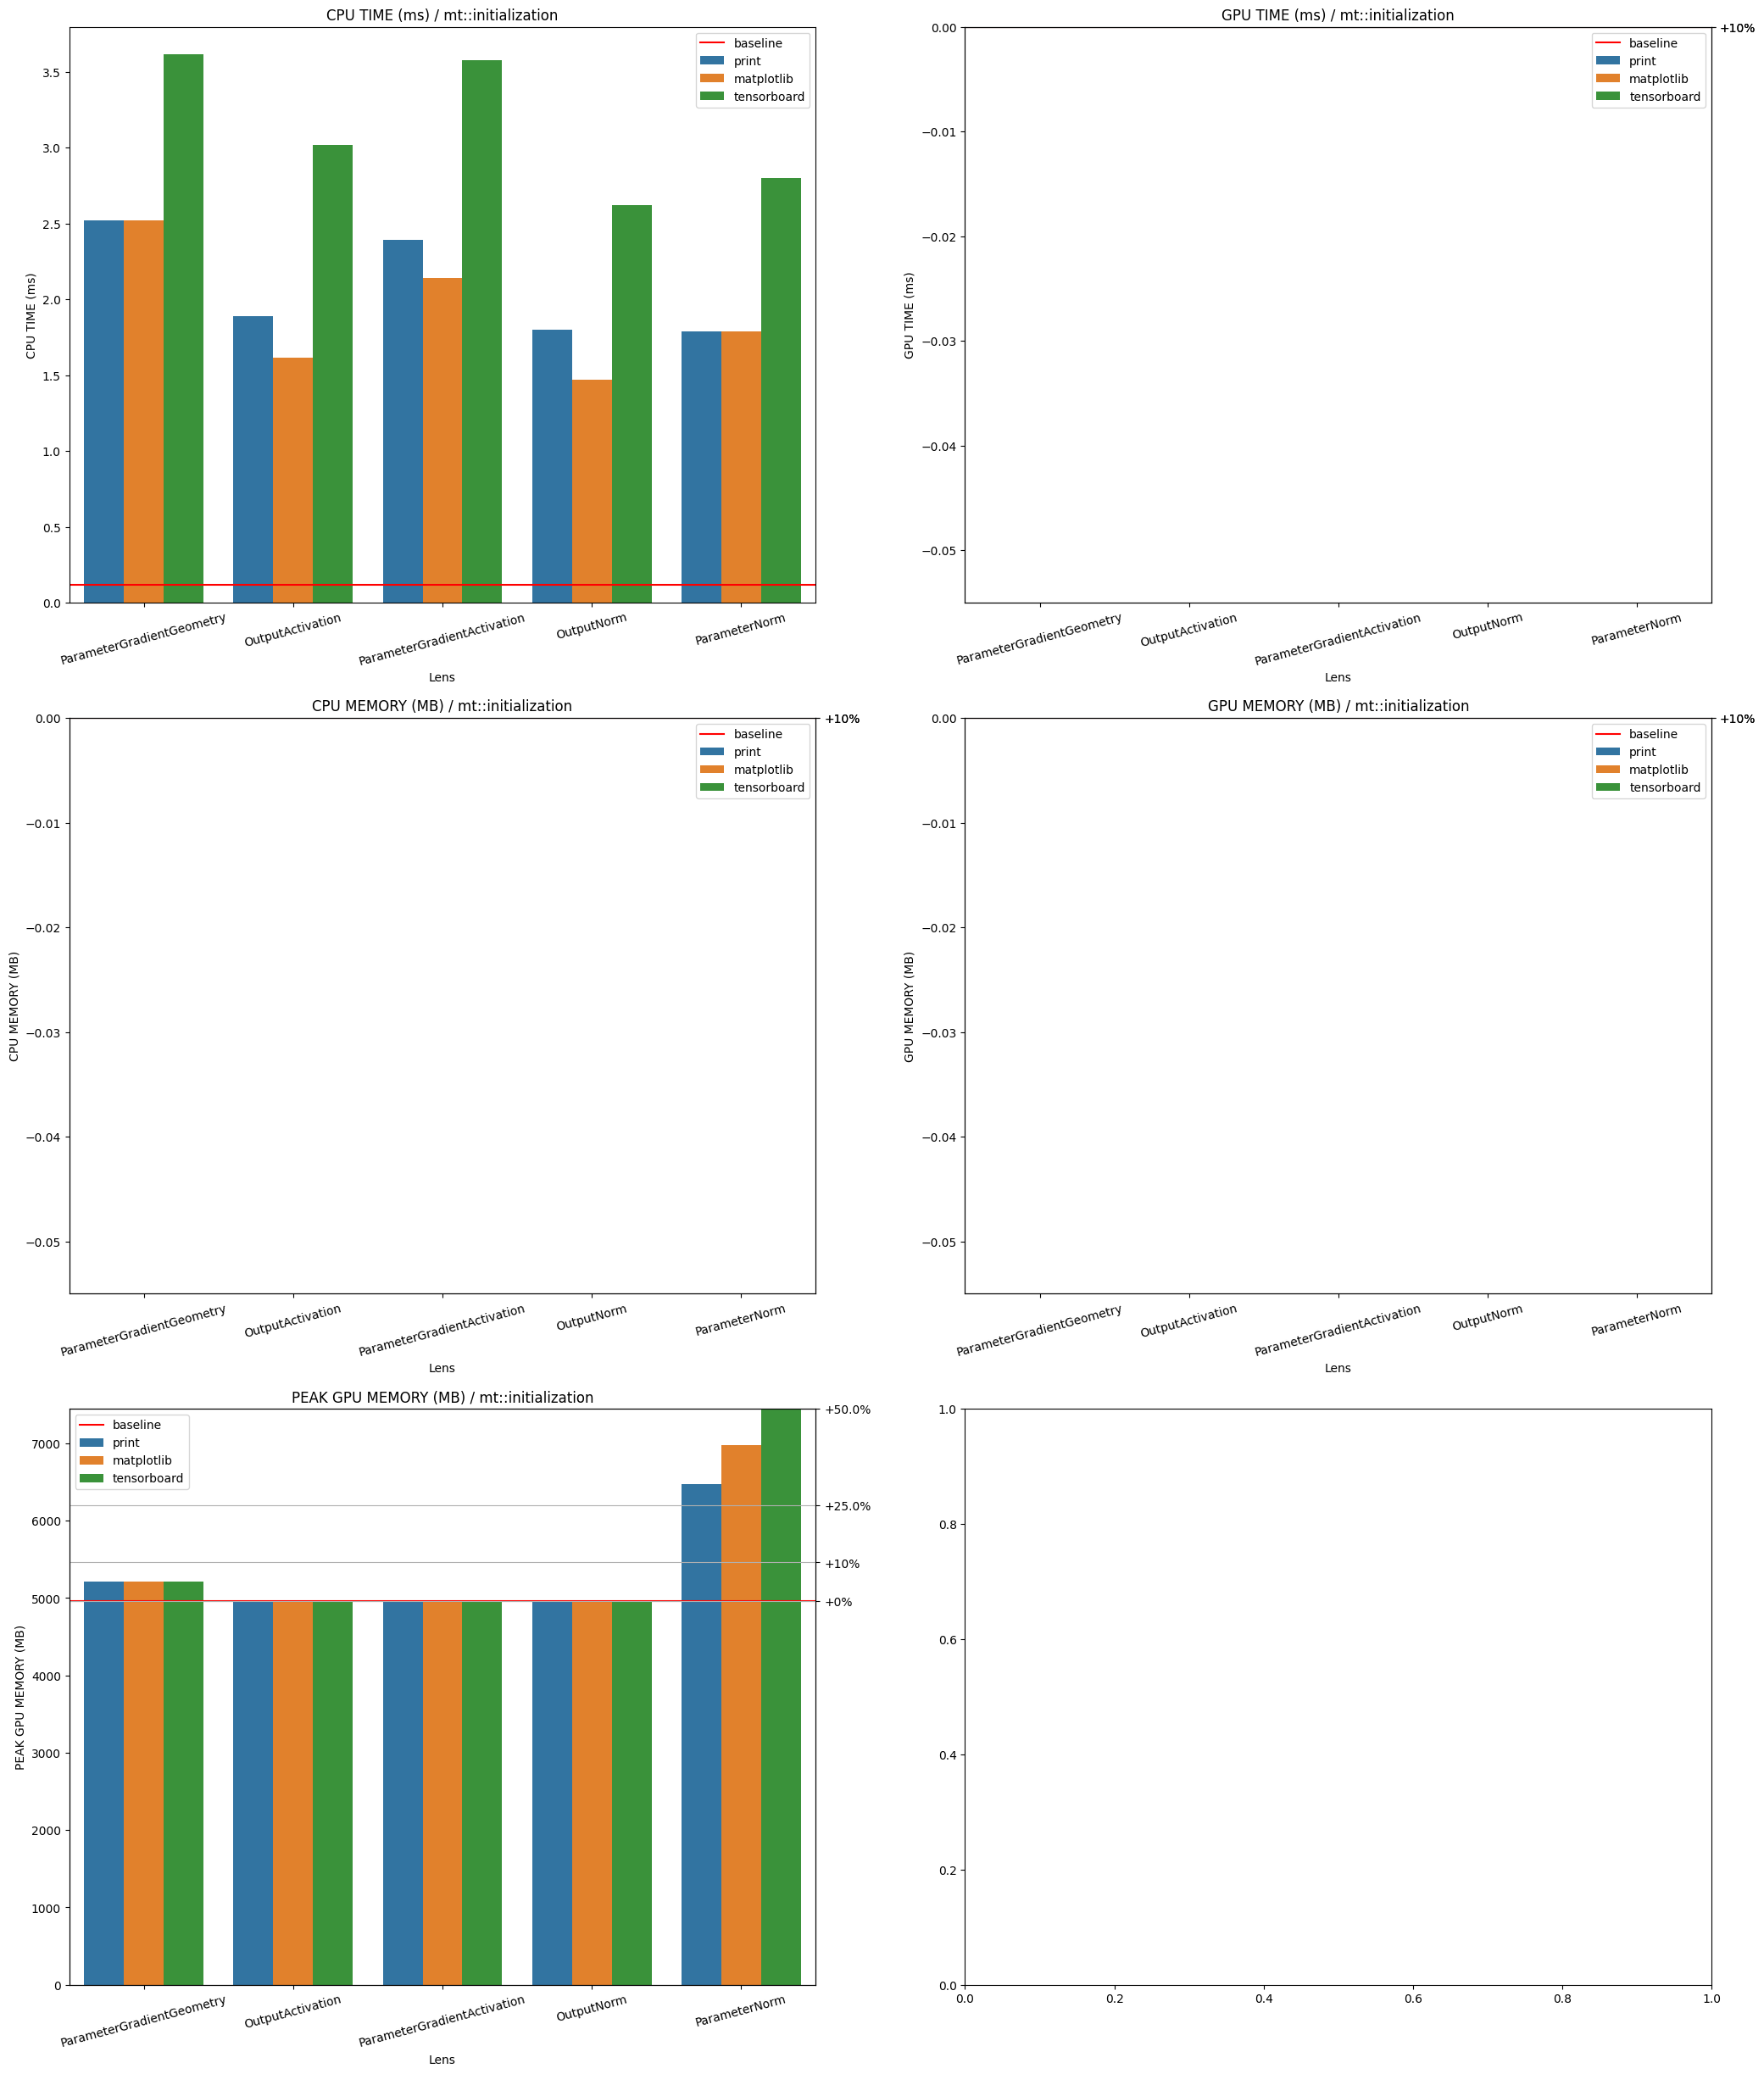

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::initialization',
        metric=metric,
        inplace=False,
        ax=axes[i],
        step=(2.00 if metric == 'CPU TIME (ms)' else 0.25)
    )

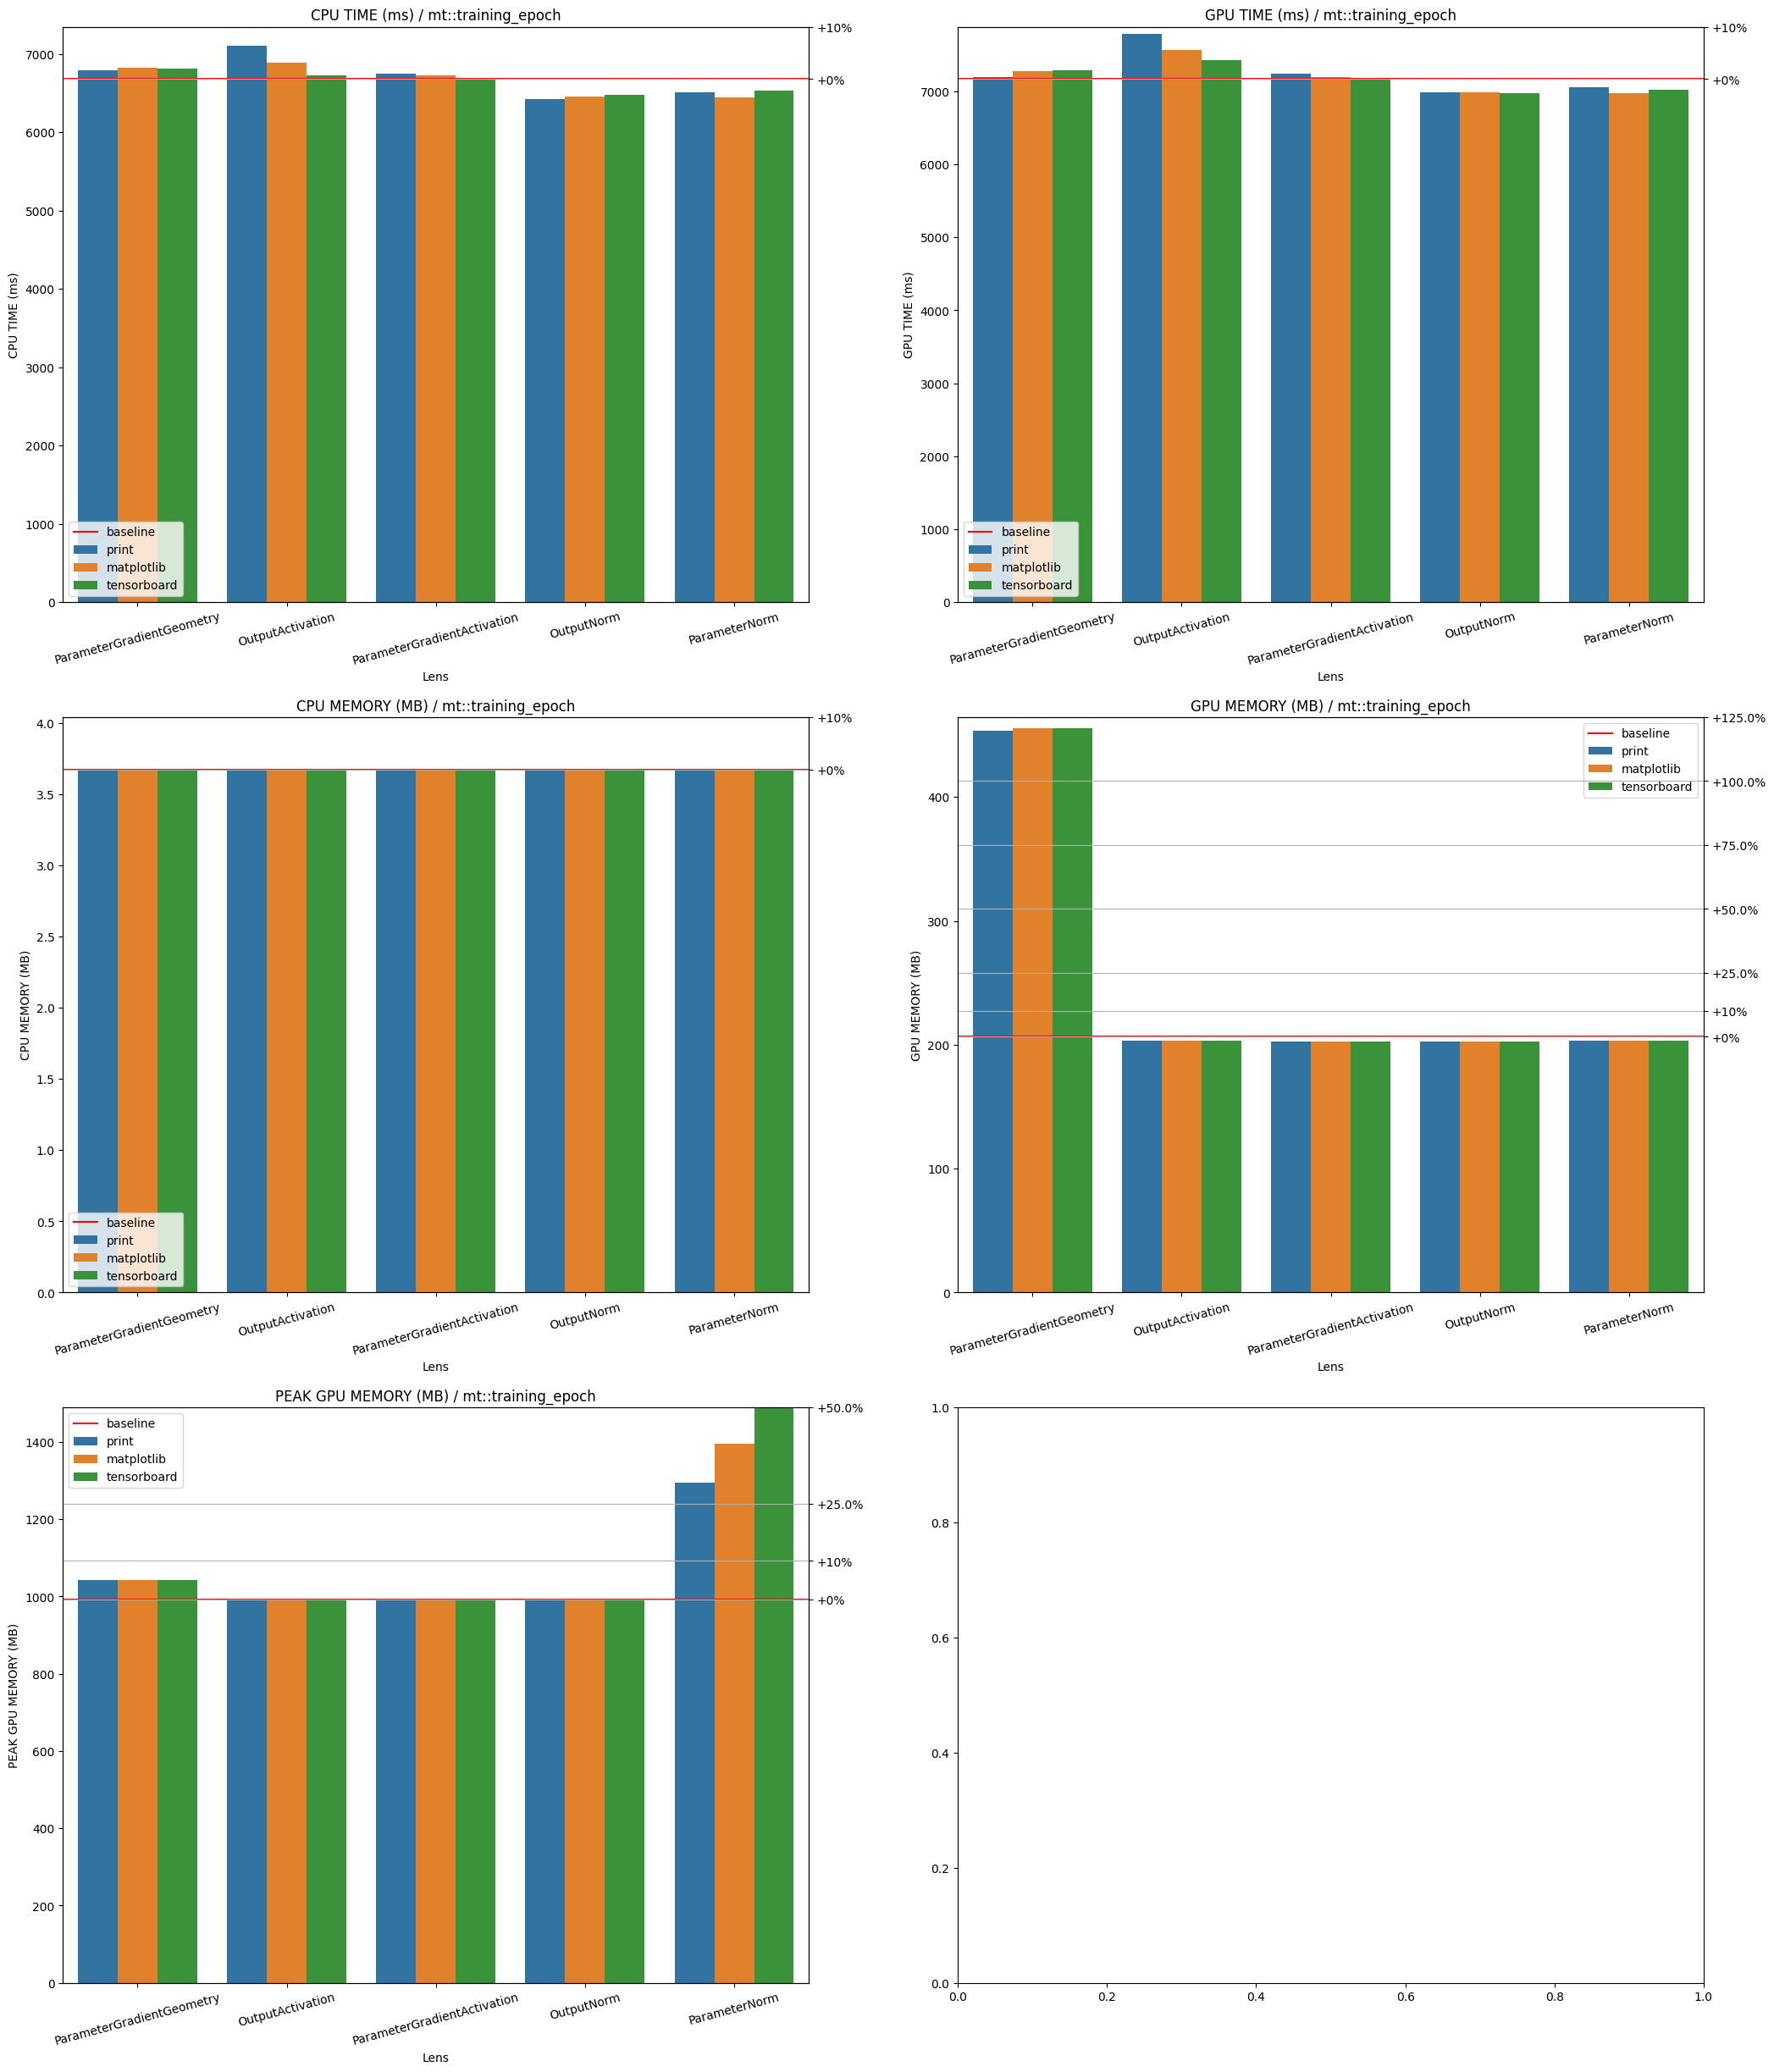

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::training_epoch',
        metric=metric,
        inplace=False,
        ax=axes[i]
    )

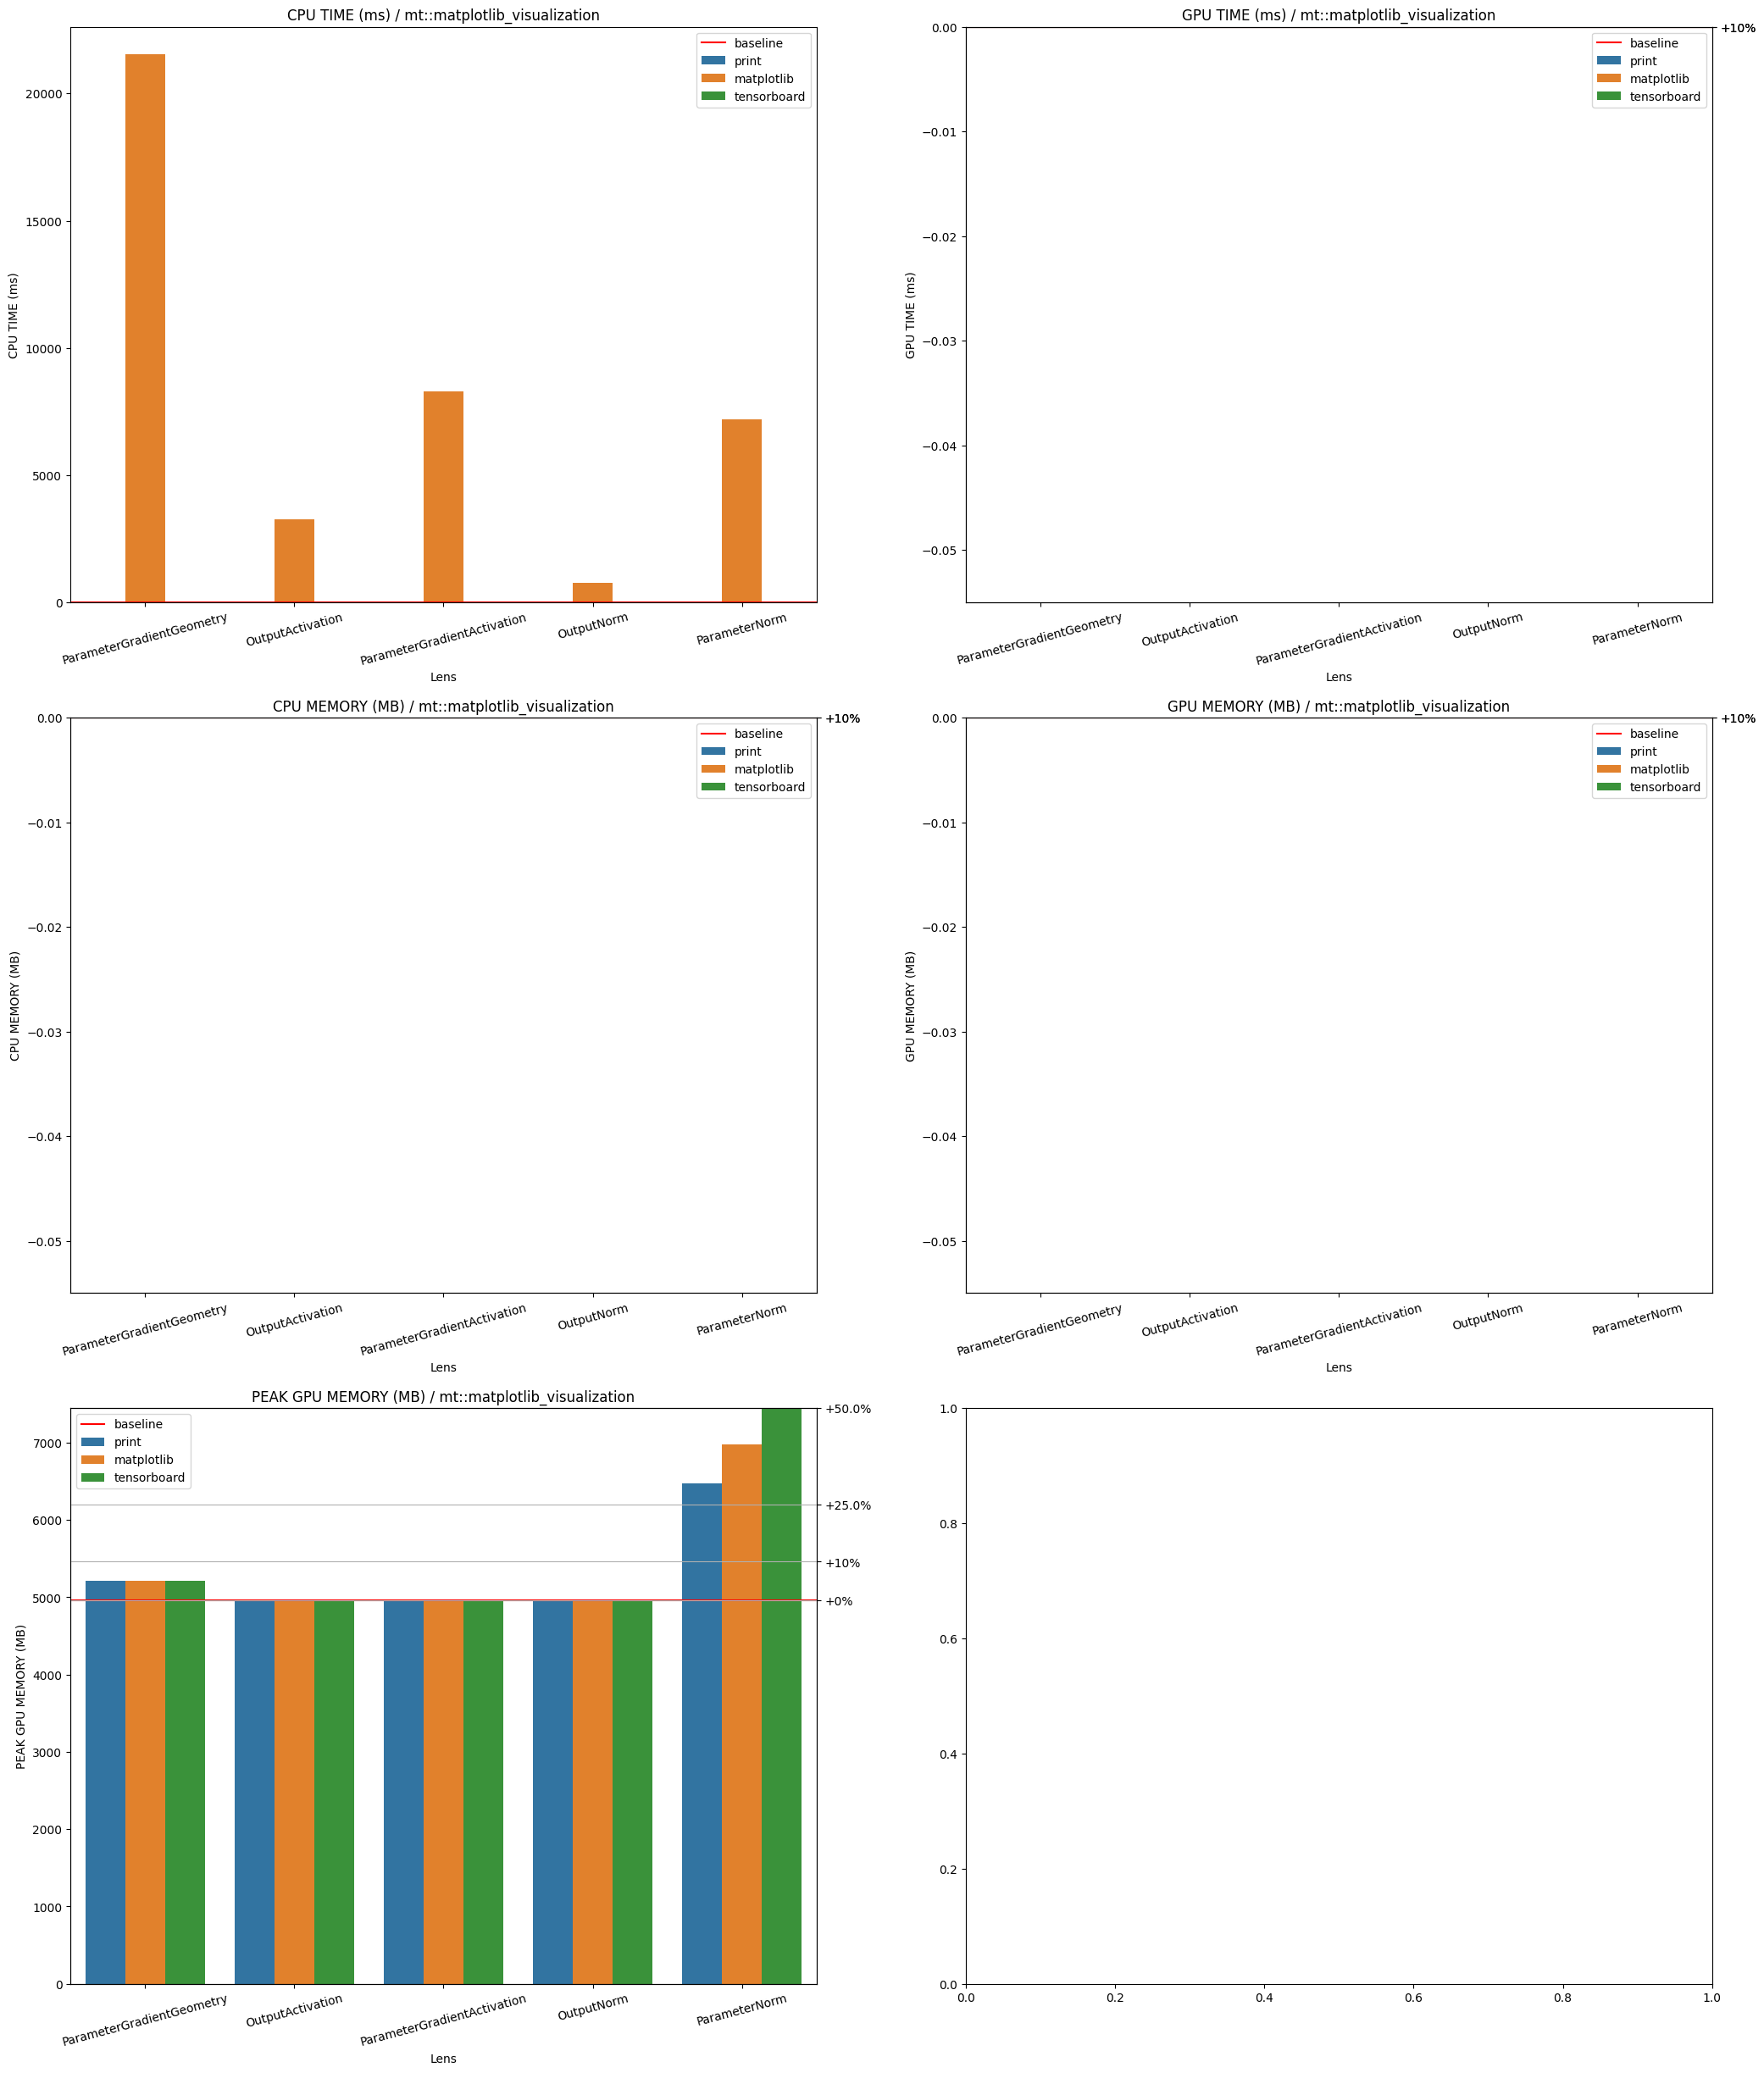

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::matplotlib_visualization',
        metric=metric,
        inplace=False,
        ax=axes[i]
    )

## Training Benchmarks

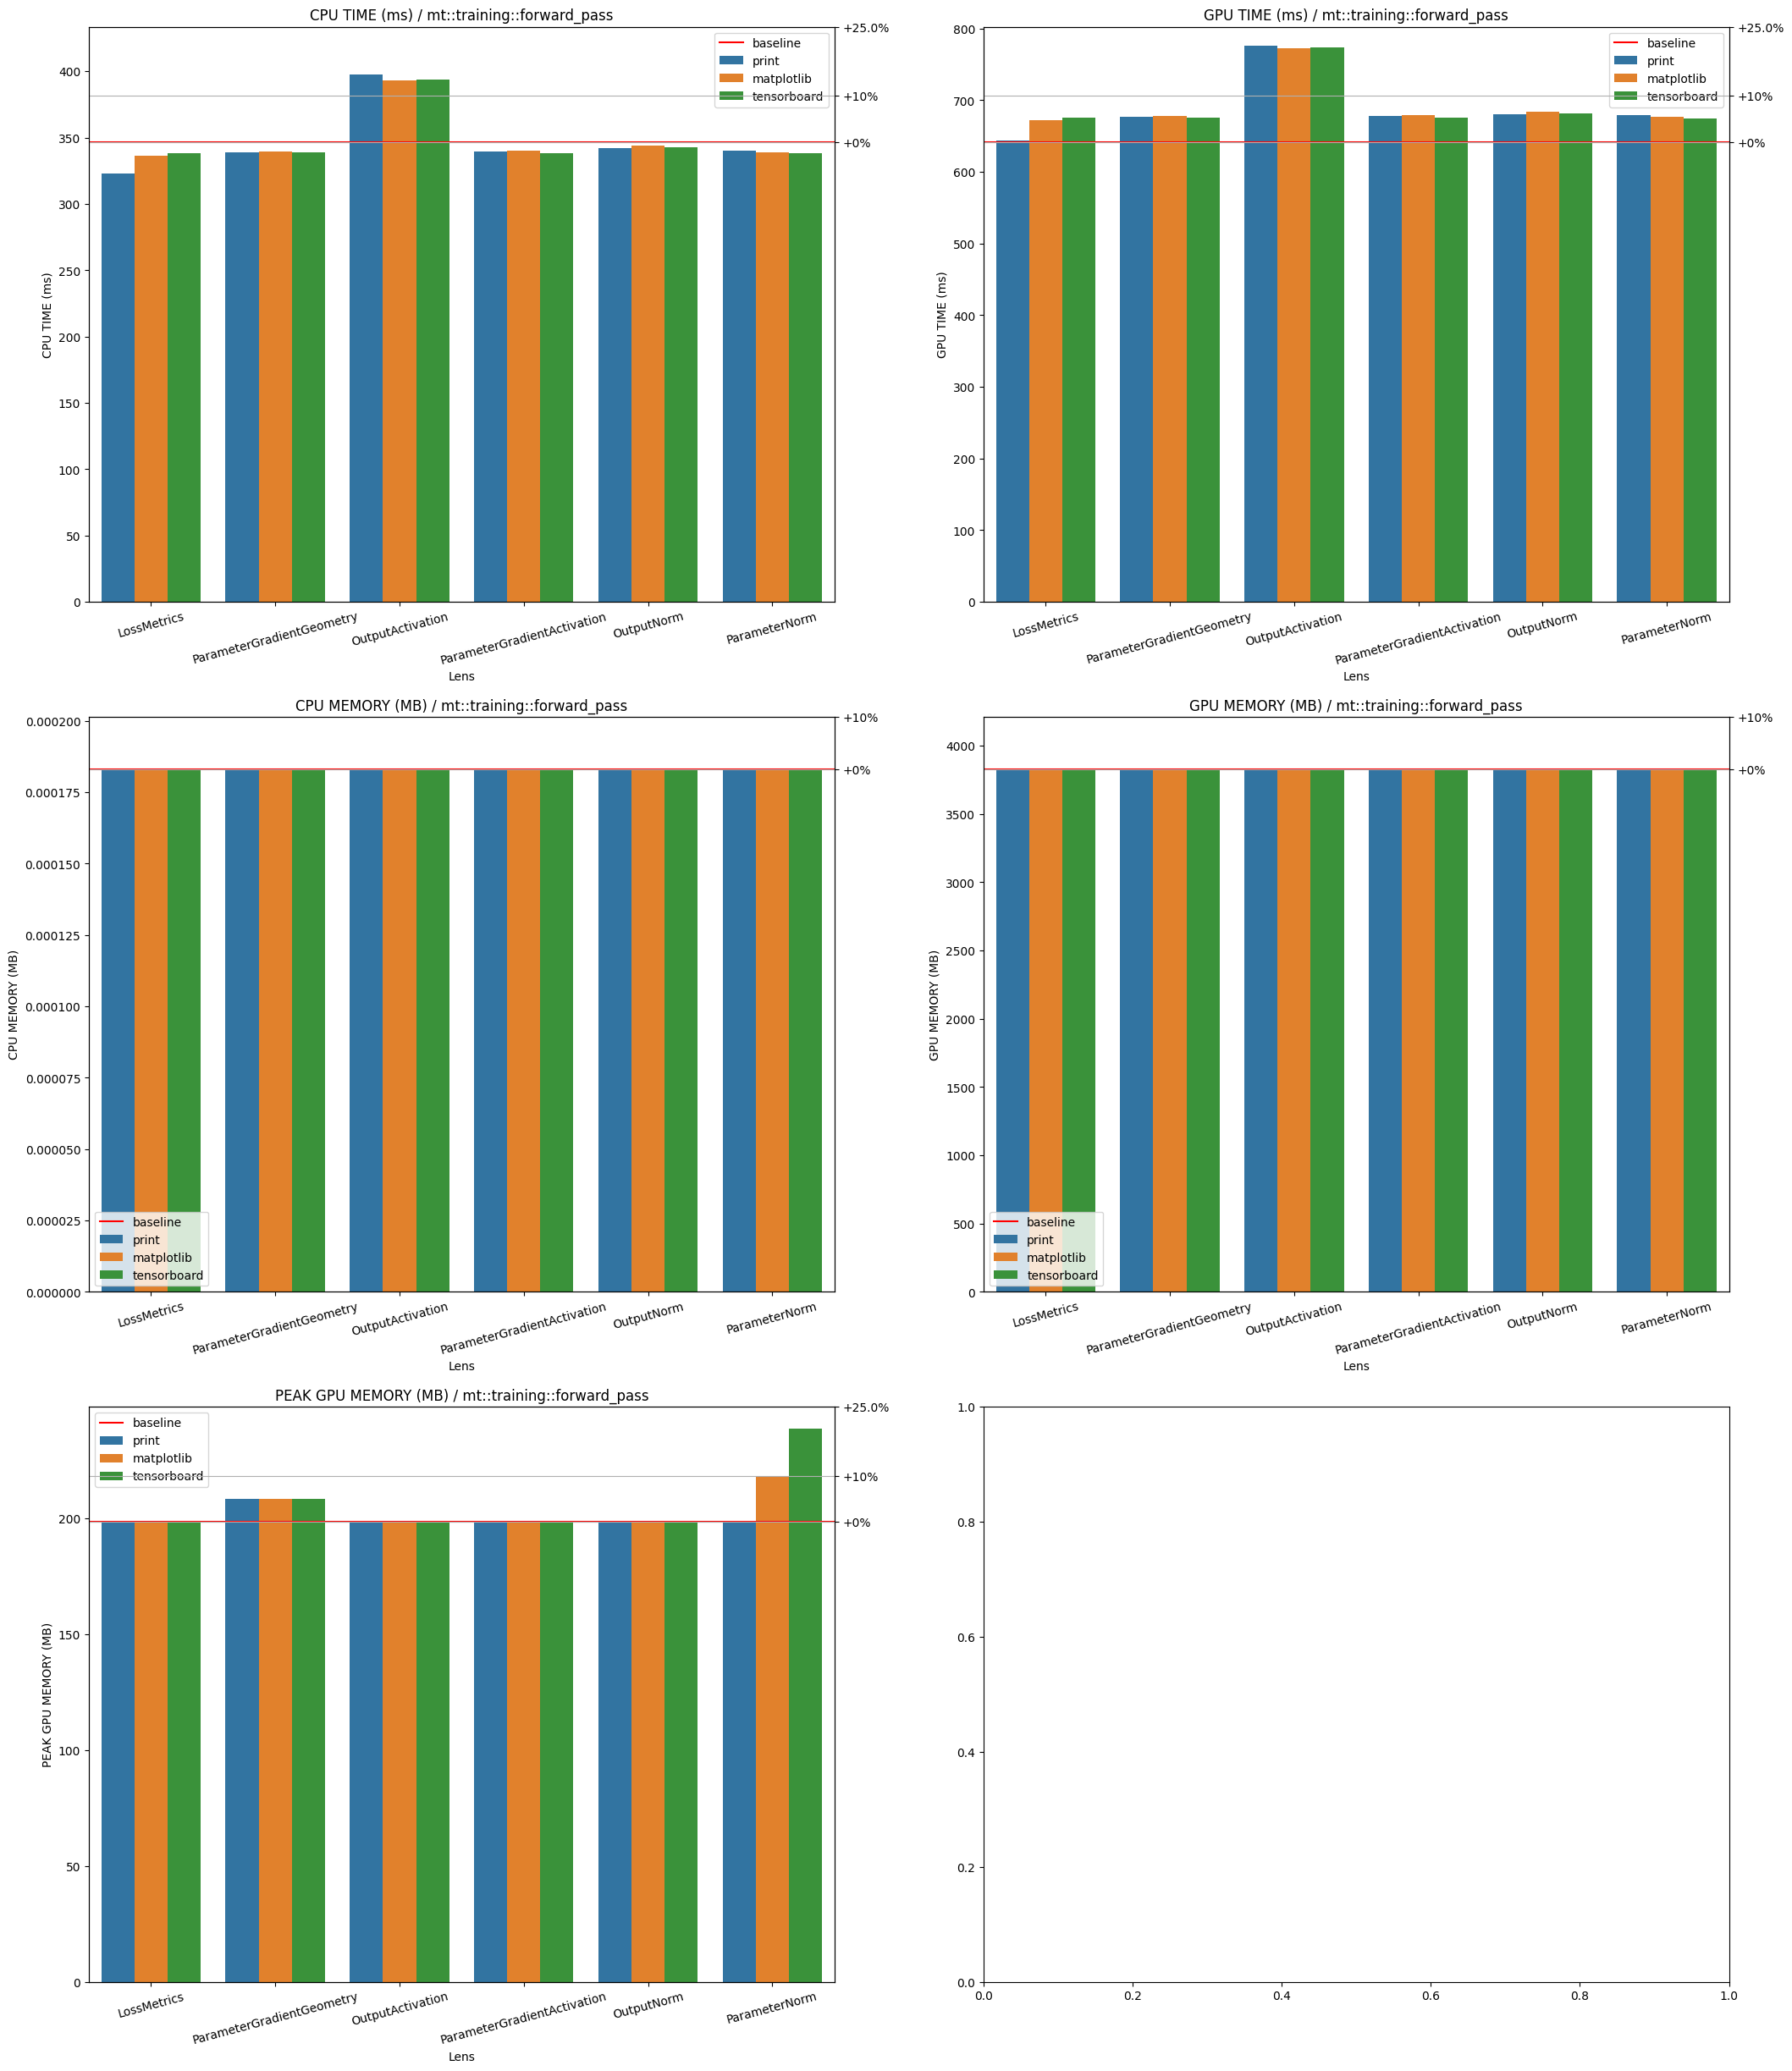

In [8]:

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::training::forward_pass',
        metric=metric,
        inplace=True,
        ax=axes[i]
    )

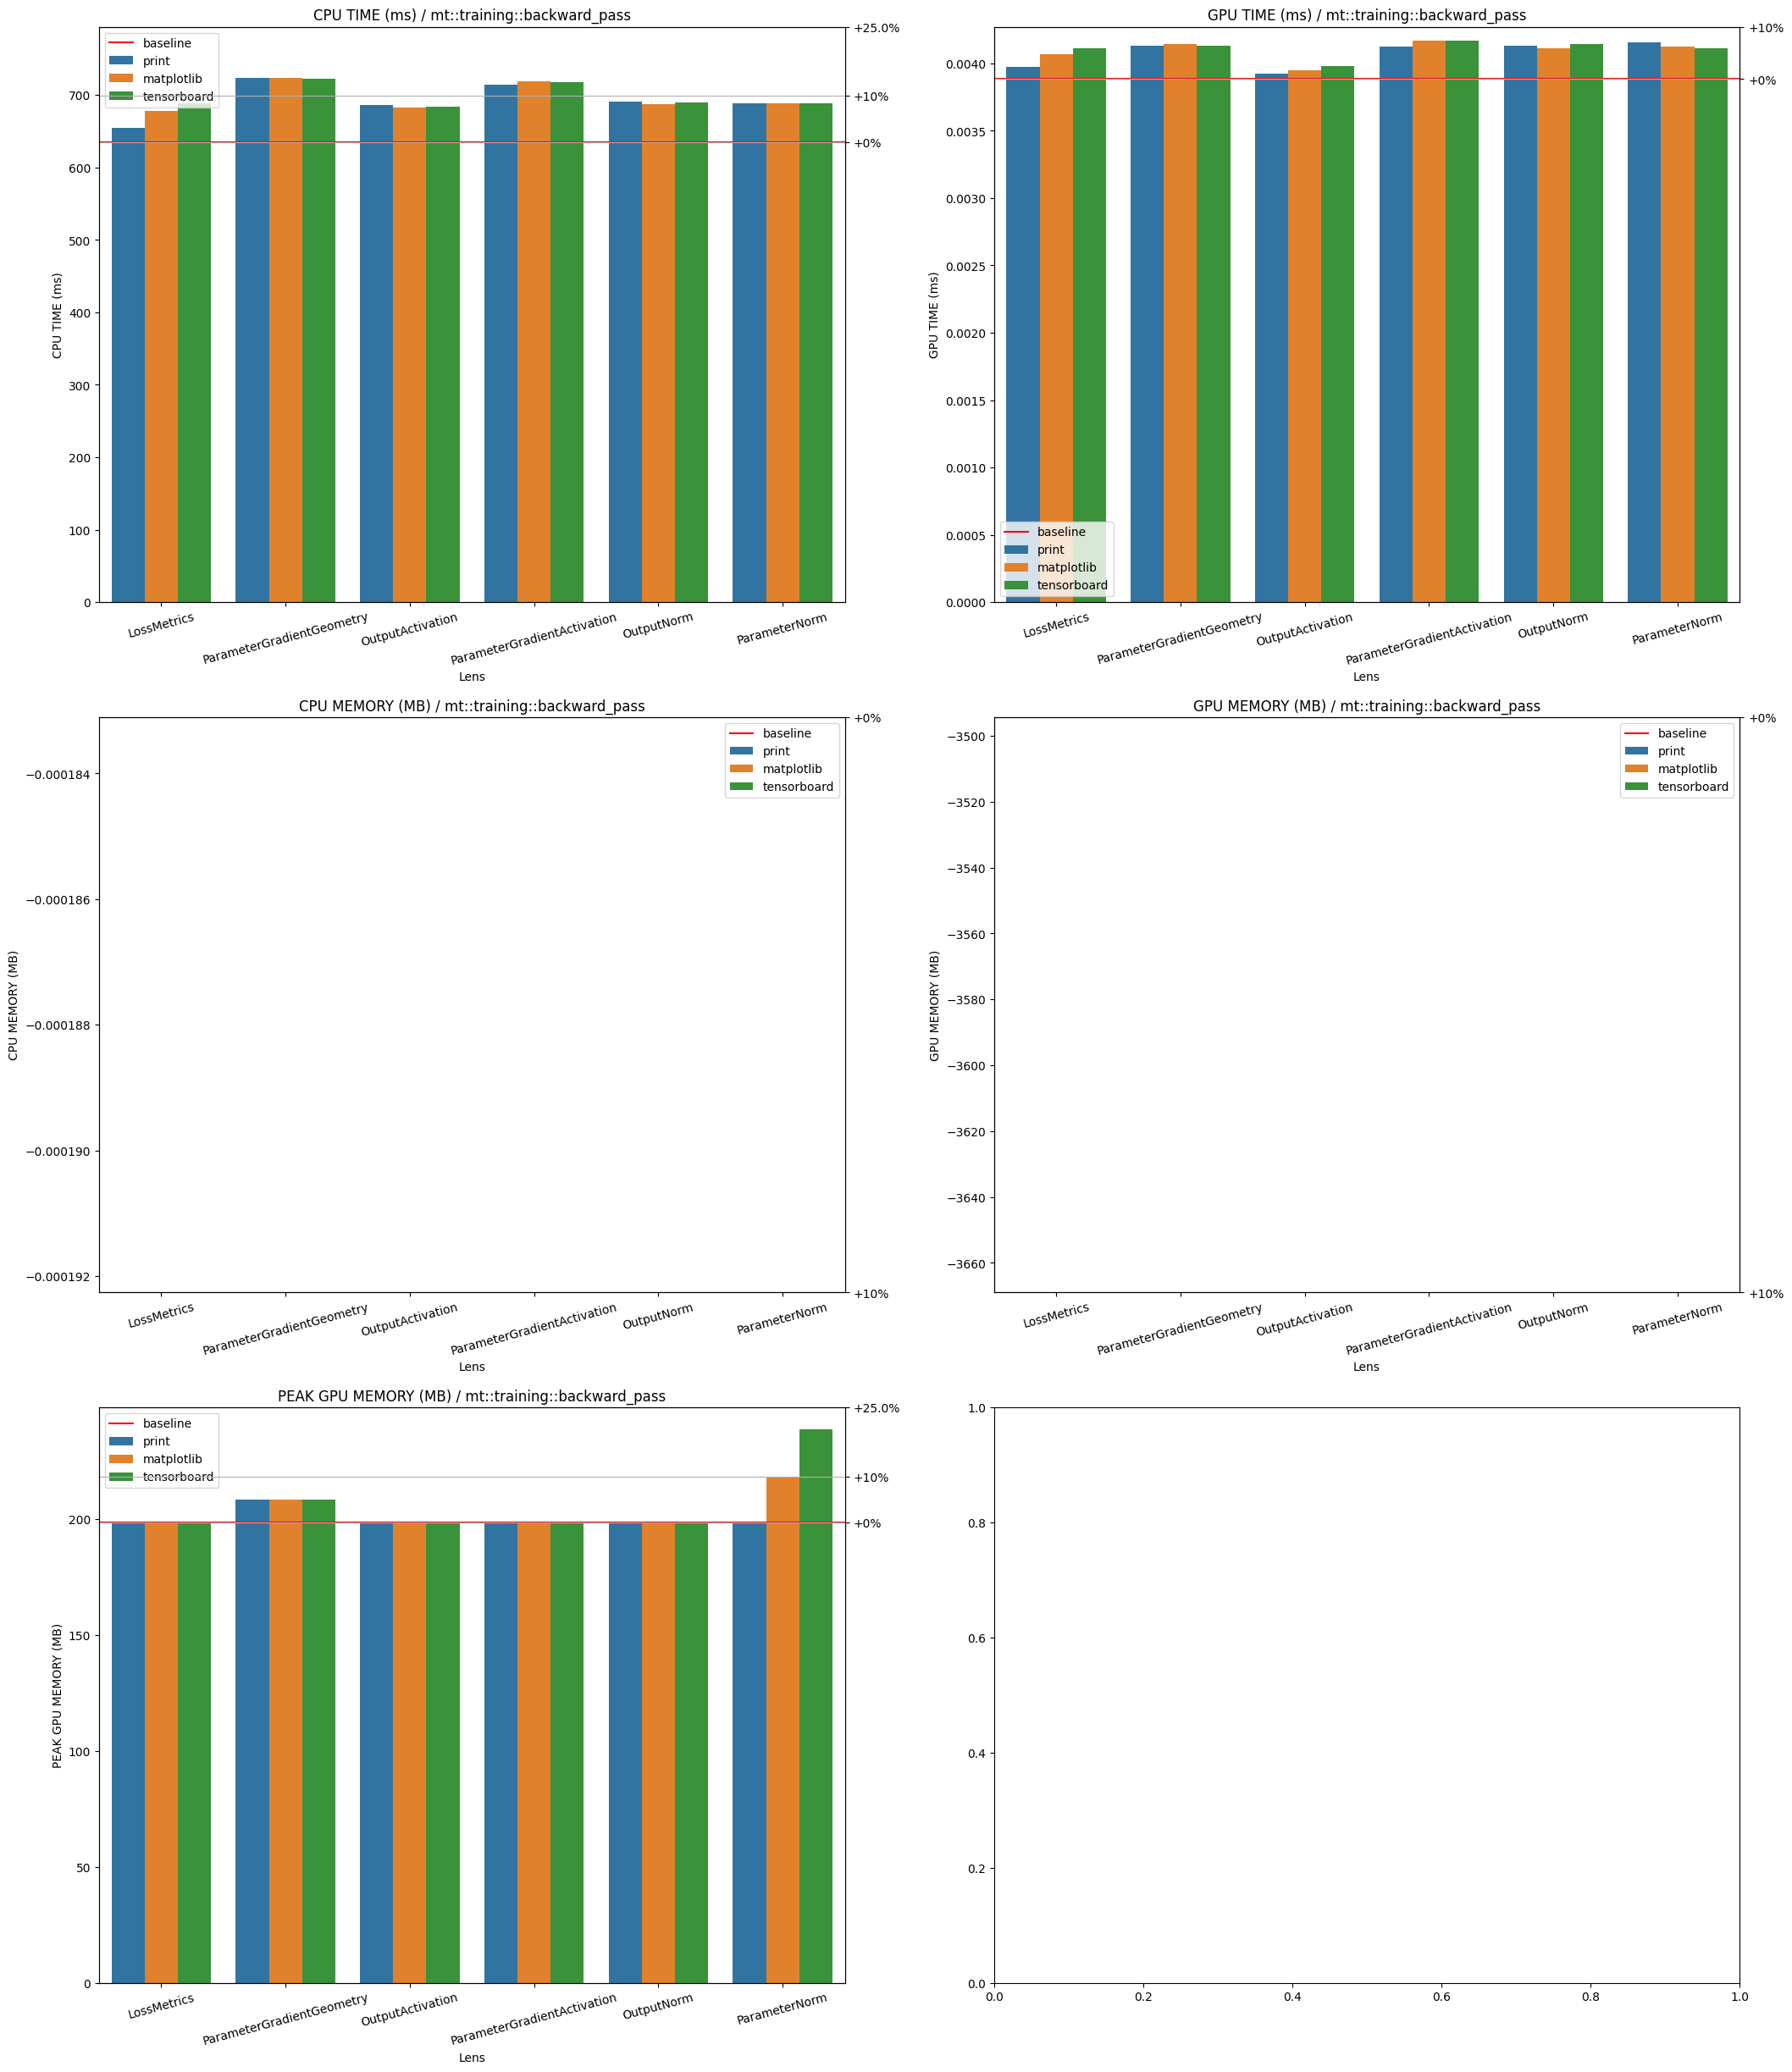

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::training::backward_pass',
        metric=metric,
        inplace=True,
        ax=axes[i]
    )

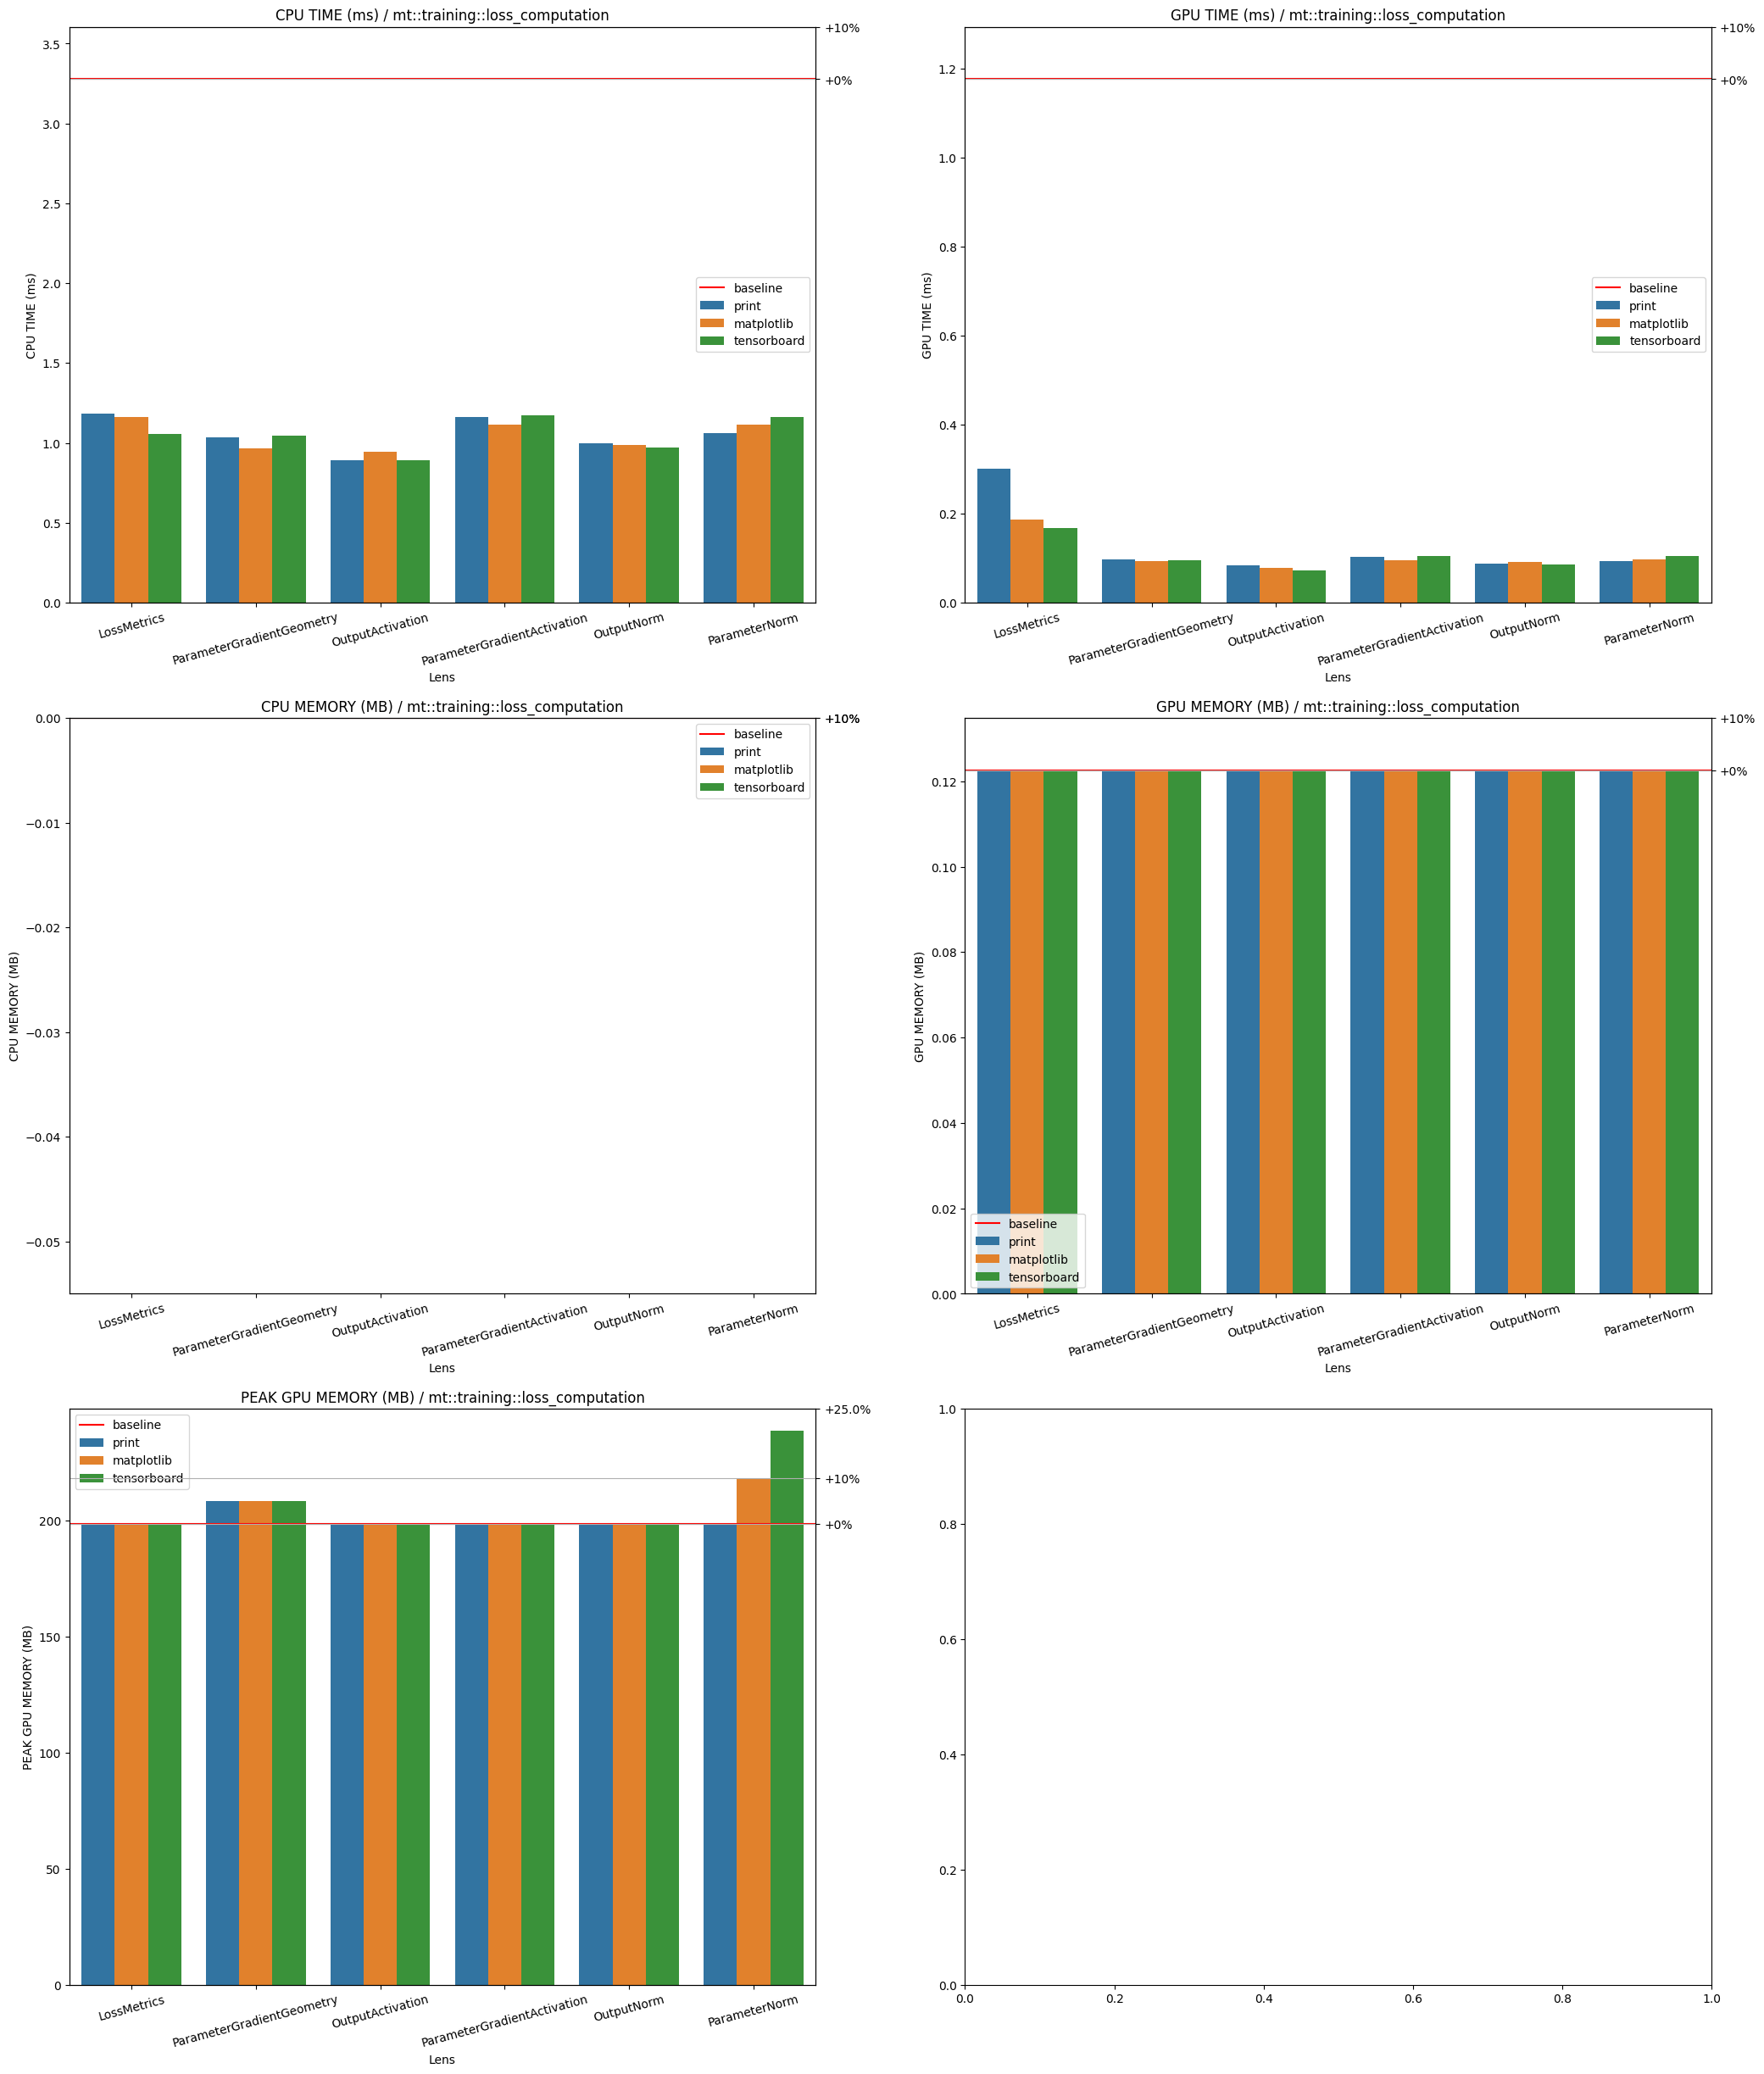

In [10]:

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::training::loss_computation',
        metric=metric,
        inplace=True,
        ax=axes[i]
    )

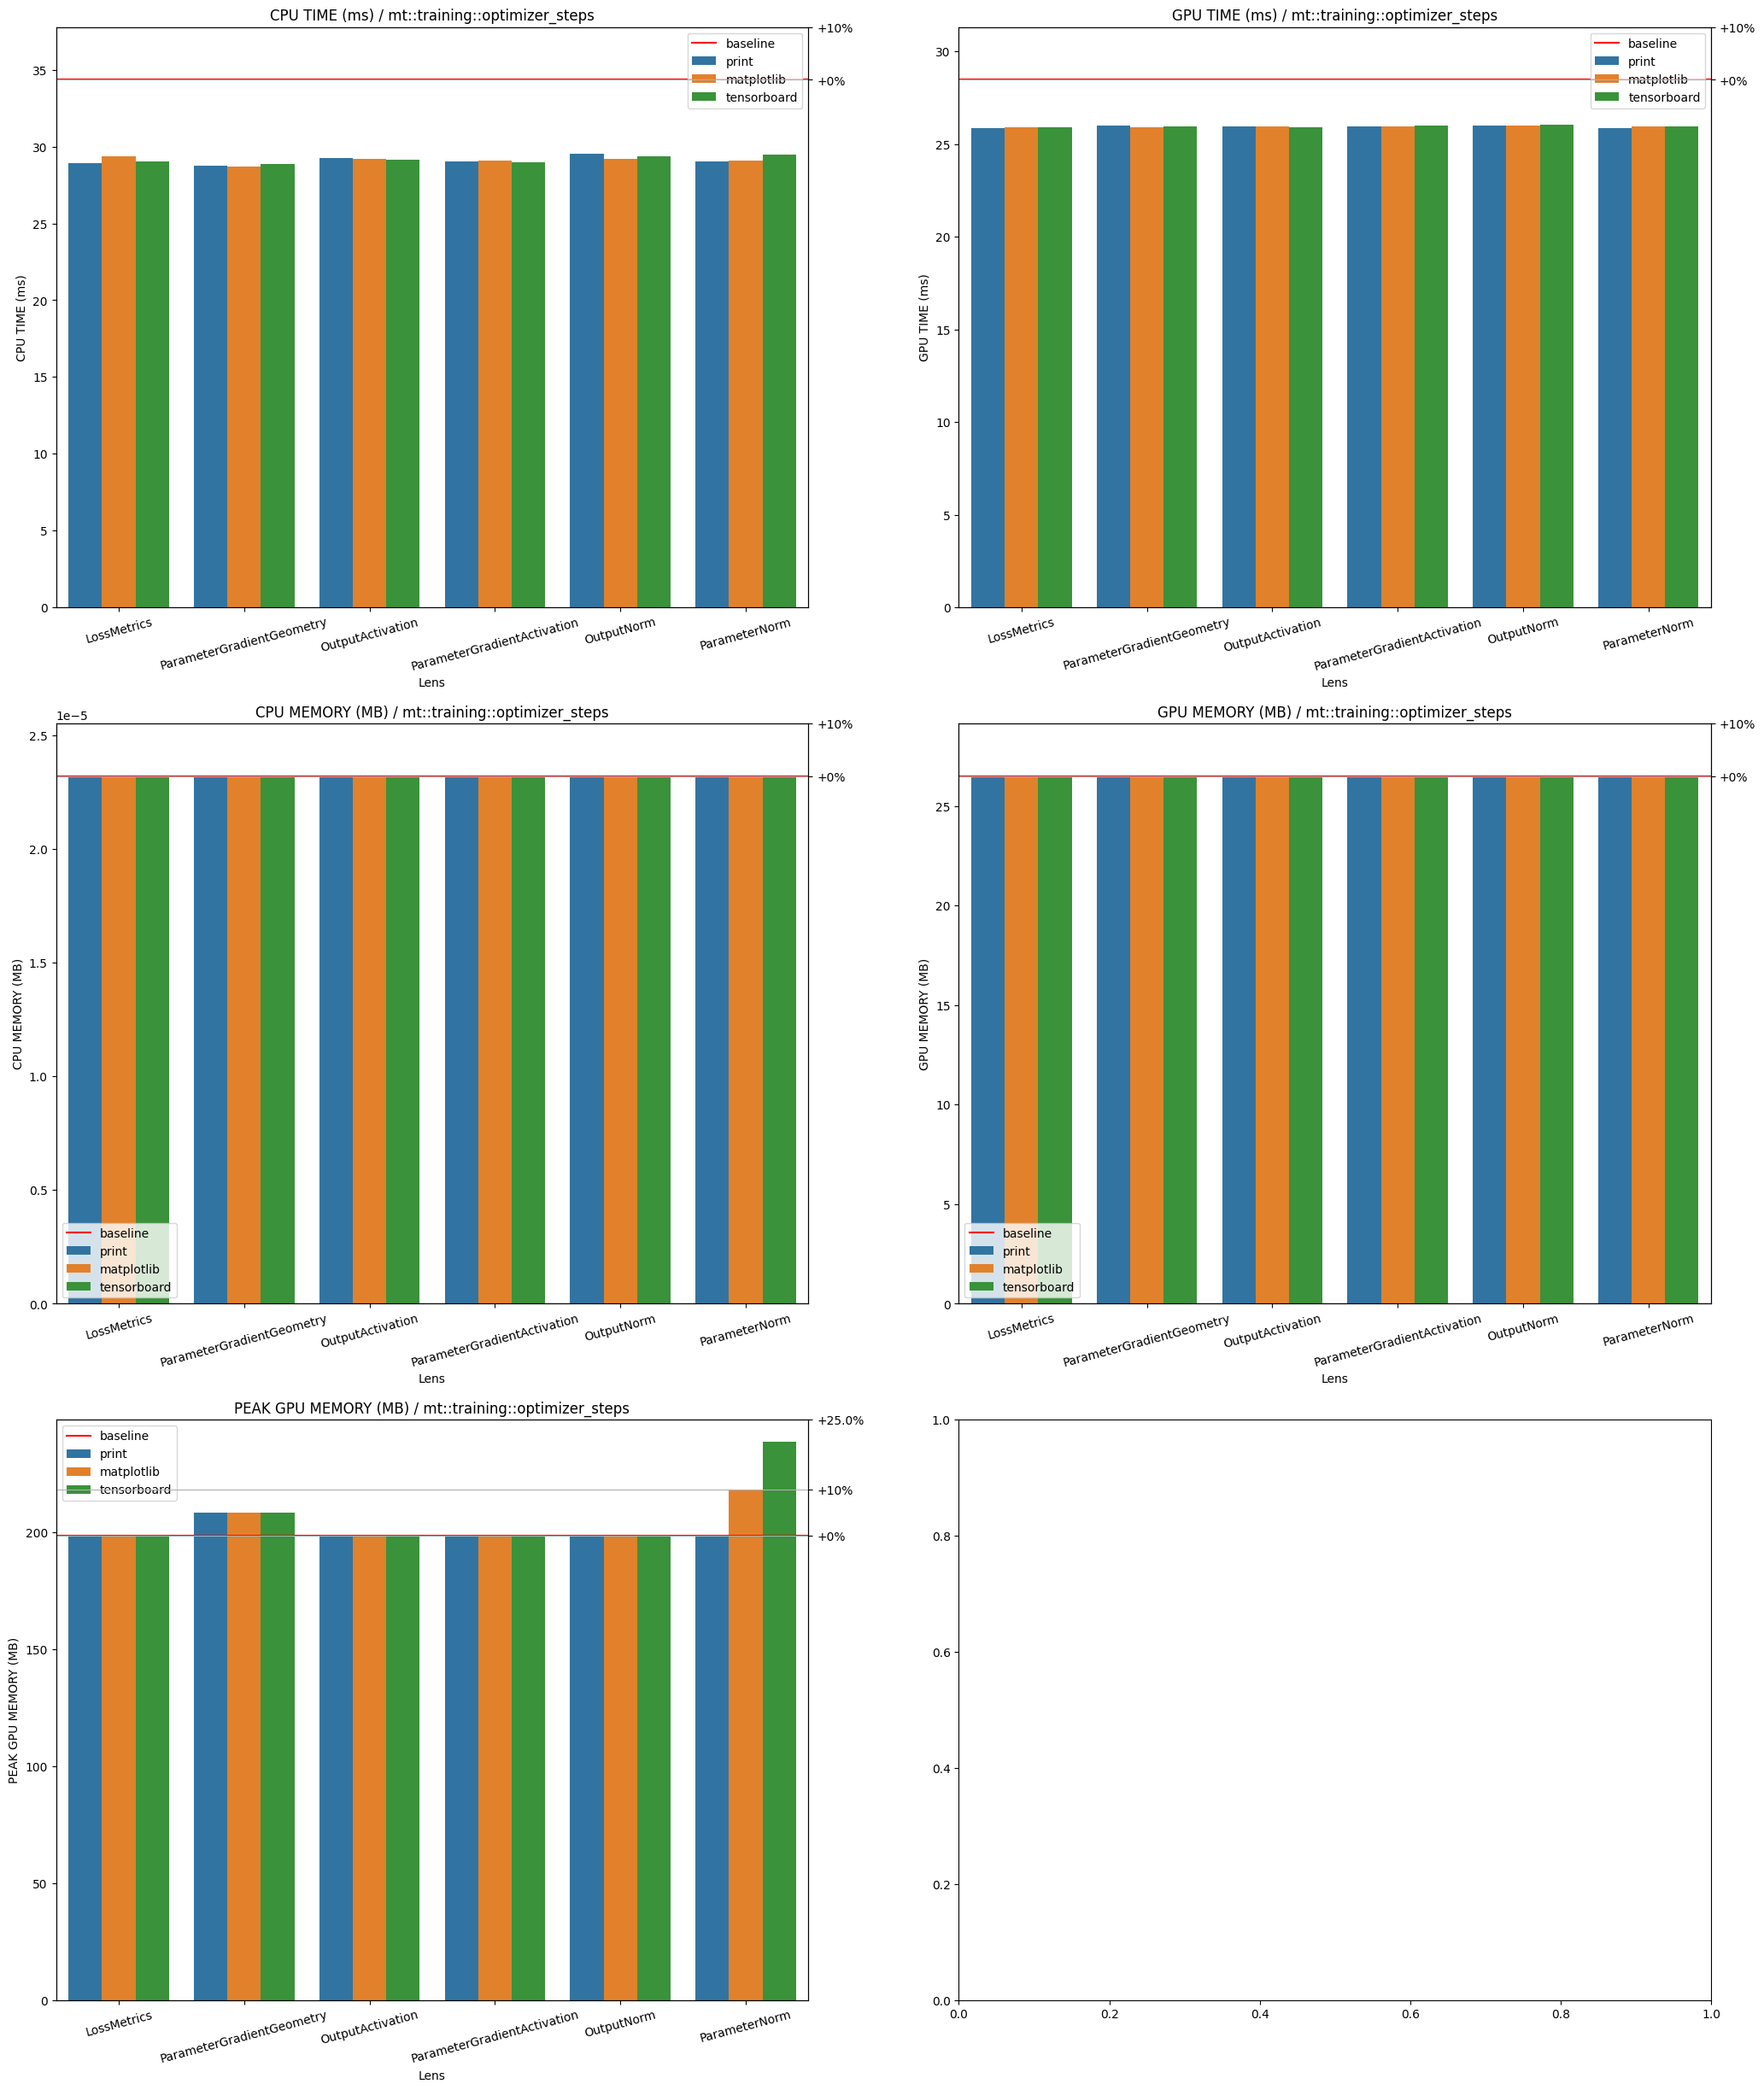

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25, 30))
axes = axes.flatten()
for i, metric in enumerate(metrics):
    display_benchmark(
        df=df,
        training_part='mt::training::optimizer_steps',
        metric=metric,
        inplace=True,
        ax=axes[i]
    )